In [1]:
import pandas as pd
from pathlib import Path

from src import ASCAT_ERA5_data_cleaning as utils
from src.general_data_cleaning_utils import plot, validate_time_index, validate_data_cleaning_input, filter_df
from src import constants as c

# Data Understanding and Preparation of the ASCAT and ERA5 Data

The goal is to generate descriptive statistics, drop missing values & outliers, and plot the data for all ASCAT and ERA5 data in `data/raw/ASCAT` and `data/raw/ERA`. The cleaned data will then be exported to their respective folders in `data/cleaned`.

---

### Table of Contents

1. **Setup**
    - *1.1 Variables*
    - *1.2 Functions*
2. **ISMN Stations**
    - *2.1 Aberdeen-35-WNW*
    - *2.2 Jamestown-38-WSW*
    - *2.3 Gobblers Knob*
    - *2.4 Nenana*
    - *2.5 L23*
    - *2.6 L38*
    - *2.7 NST-07*
    - *2.8 NST-09*
    - *2.9 SOD012*
    - *2.10 SOD103*

---

## 1. Setup

### 1.1 Variables

In [2]:
# key columns
ASCAT_short_var_name = 'backscatter40'
ERA5_short_var_name = 'stl1'
ASCAT_long_var_name = '40° Normalized Backscatter (dB)'
ERA5_long_var_name = 'Soil Temperature Level 1 (C)'

# path variables
ASCAT = 'ASCAT'
ERA5 = 'ERA5'
raw_path = Path('../data/raw/ASCAT_ERA5')
cleaned_path = Path('../data/cleaned')
Path(cleaned_path / ASCAT).mkdir(parents=True, exist_ok=True)
Path(cleaned_path / ERA5).mkdir(parents=True, exist_ok=True)

### 1.2 Functions

In [3]:
def data_cleaning(data_path: Path, ismn_sites_path: Path,
                  station: str, system: str, key_variable: str,
                  date_range=None) -> pd.DataFrame:
    """
    Preprocessing of raw ASCAT or ERA5 data.
    :param data_path: path to csv file
    :param ismn_sites_path: path to csv file containing ISMN site information
    :param station: must match exactly name in ISMN_site_survey.csv
    :param system: ASCAT or ERA5, case-insensitive
    :param key_variable: name of variable of interest (in csv)
    :param date_range: list of datetime objects. Data outside this range is filtered out. Min is inclusive and max is exclusive. Assumed that input is in the same timezone as df.index. If date_range is not valid for given df, date_range will be adjusted to be valid.
    :return: cleaned dataframe
    """
    # validate inputs
    validate_data_cleaning_input(data_path, date_range)

    df = utils.collect_data(data_path, ismn_sites_path, station, system)
    utils.check_df_cols(df, system)

    # report NaN count and proportion
    na_count = df.isnull().sum()[key_variable]
    print(f'There are {na_count} nulls out of {len(df)} datapoints ({round(na_count/len(df),2)}% missing).')

    df = df.dropna(subset=[key_variable]) # interpolation not recommended
    df = utils.round_nearest_hour_index(df)
    df = filter_df(df, date_range=date_range)

    return df

def data_reporting(df: pd.DataFrame, variable: str, station_name: str, system: str, ylabel: str) -> None:
    """
    Reporting of preprocessed ASCAT and ERA5 data.
    :param df: can be output from soil_temp_data_cleaning()
    :param variable: full variable name
    :param station_name: official name of ISMN station
    :param system: name of sensor system
    :param ylabel: y-label for plot
    :return:
    """
    # check input values
    if variable not in df.columns:
        raise KeyError(f'df missing required column "{variable}".')
    # check input df index
    validate_time_index(df)

    print('Summary statistics:')
    display(df.describe())
    print('Show head of df:')
    display(df.head())

    plot(df, variable, station=station_name, system=system, form='line', y_label=ylabel)

## 2. ISMN Stations

### 2.1 Aberdeen-35-WNW

#### ASCAT

There are 1618 nulls out of 17799 datapoints (0.09% missing).
Summary statistics:


,backscatter40,swath_indicator,as_des_pass,sat_id
count,16181.000000,16181.000000,16181.000000,16181.000000
mean,-14.759586,0.497497,0.490328,3.727458
std,1.715188,0.500009,0.499922,0.751516
min,-19.637800,0.000000,0.000000,3.000000
25%,-15.928318,0.000000,0.000000,3.000000
50%,-14.600672,0.000000,0.000000,4.000000
75%,-13.589661,1.000000,1.000000,4.000000
max,-6.488361,1.000000,1.000000,5.000000


Show head of df:


,backscatter40,swath_indicator,as_des_pass,sat_id
time,,,,
2007-01-01 04:00:00+00:00,-18.138327,1,0,3
2007-01-02 04:00:00+00:00,-18.249712,1,0,3
2007-01-02 16:00:00+00:00,-18.546434,1,1,3
2007-01-03 17:00:00+00:00,-17.615808,0,1,3
2007-01-04 03:00:00+00:00,-15.992000,0,0,3


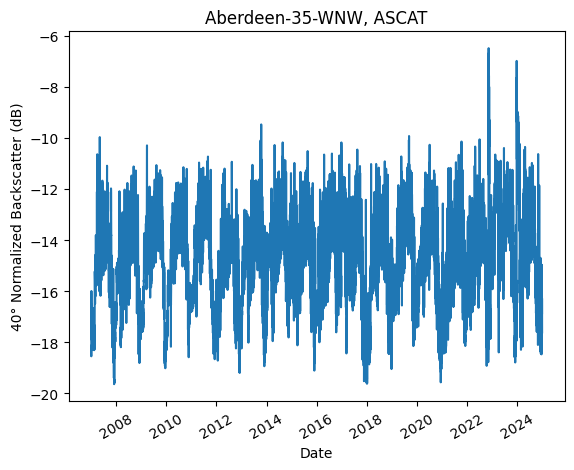

In [4]:
ASCAT_Aberdeen_df = data_cleaning(data_path=raw_path,
                                  ismn_sites_path=c.SITE_SURVEY_PATH,
                                  station=c.ABERDEEN_NAME,
                                  system=ASCAT,
                                  key_variable=ASCAT_short_var_name,
                                  date_range=c.DATE_RANGE)
data_reporting(df=ASCAT_Aberdeen_df,
               variable=ASCAT_short_var_name,
               station_name=c.ABERDEEN_NAME,
               system=ASCAT,
               ylabel=ASCAT_long_var_name)

#### ERA5

There are 0 nulls out of 27760 datapoints (0.0% missing).
Summary statistics:


,skt,stl1,stl2,swvl1,swvl2,sd
count,26300.000000,26300.000000,26300.000000,26300.000000,26300.000000,26300.000000
mean,6.491117,8.076804,8.347241,0.277745,0.265314,0.007359
std,14.141269,11.086022,10.018990,0.063695,0.057899,0.018629
min,-38.990770,-25.262360,-15.971466,0.130465,0.132934,0.000000
25%,-3.884247,-1.368675,-1.037155,0.223478,0.220015,0.000000
50%,6.868408,7.214417,7.404221,0.280231,0.261418,0.000000
75%,17.465072,17.849426,18.184876,0.324517,0.306230,0.002933
max,41.235810,33.542816,28.915863,0.439208,0.437051,0.121290


Show head of df:


,skt,stl1,stl2,swvl1,swvl2,sd
time,,,,,,
2007-01-01 00:00:00+00:00,-8.824951,-3.689606,-1.241242,0.236350,0.243425,0.011896
2007-01-01 06:00:00+00:00,-10.743195,-6.642731,-1.306000,0.236399,0.243433,0.011884
2007-01-01 12:00:00+00:00,-12.849762,-8.534576,-1.427521,0.236382,0.243390,0.011883
2007-01-01 18:00:00+00:00,-6.766449,-4.998962,-1.519897,0.236419,0.243401,0.011862
2007-01-02 00:00:00+00:00,-10.536652,-3.941009,-1.538055,0.236313,0.243309,0.011836


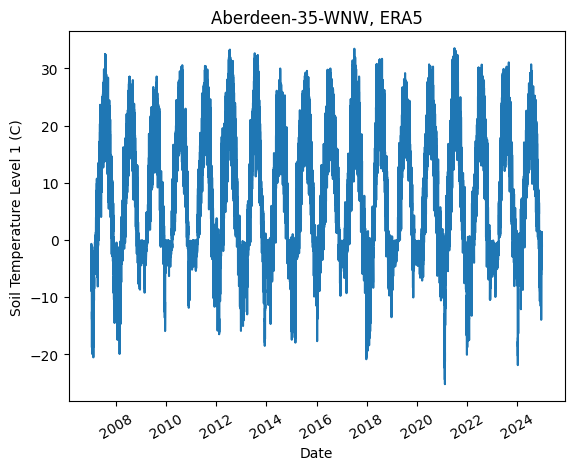

In [5]:
ERA5_aberdeen_df = data_cleaning(data_path=raw_path,
                                 ismn_sites_path=c.SITE_SURVEY_PATH,
                                 station=c.ABERDEEN_NAME,
                                 system=ERA5,
                                 key_variable=ERA5_short_var_name,
                                 date_range=c.DATE_RANGE)
data_reporting(df=ERA5_aberdeen_df,
               variable=ERA5_short_var_name,
               station_name=c.ABERDEEN_NAME,
               system=ERA5,
               ylabel=ERA5_long_var_name)

### 2.2 Jamestown-38-WSW

#### ASCAT

There are 2199 nulls out of 18830 datapoints (0.12% missing).
Summary statistics:


,backscatter40,swath_indicator,as_des_pass,sat_id
count,16631.000000,16631.000000,16631.000000,16631.000000
mean,-14.562716,0.484878,0.495280,3.726054
std,1.587096,0.499786,0.499993,0.749018
min,-19.451506,0.000000,0.000000,3.000000
25%,-15.598405,0.000000,0.000000,3.000000
50%,-14.439528,0.000000,0.000000,4.000000
75%,-13.442534,1.000000,1.000000,4.000000
max,-6.382537,1.000000,1.000000,5.000000


Show head of df:


,backscatter40,swath_indicator,as_des_pass,sat_id
time,,,,
2007-01-01 04:00:00+00:00,-18.511513,1,0,3
2007-01-02 04:00:00+00:00,-18.238005,1,0,3
2007-01-02 16:00:00+00:00,-18.214222,1,1,3
2007-01-03 17:00:00+00:00,-15.158000,0,1,3
2007-01-04 03:00:00+00:00,-14.611470,0,0,3


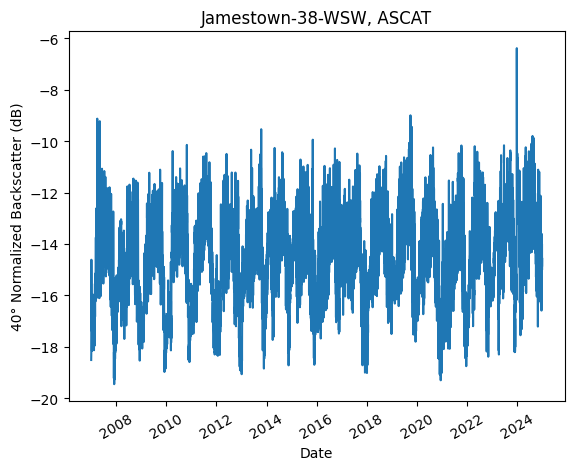

In [6]:
ASCAT_jamestown_df = data_cleaning(data_path=raw_path,
                                   ismn_sites_path=c.SITE_SURVEY_PATH,
                                   station=c.JAMESTOWN_NAME,
                                   system=ASCAT,
                                   key_variable=ASCAT_short_var_name,
                                   date_range=c.DATE_RANGE)
data_reporting(df=ASCAT_jamestown_df,
               variable=ASCAT_short_var_name,
               station_name=c.JAMESTOWN_NAME,
               system=ASCAT,
               ylabel=ASCAT_long_var_name)

#### ERA5

There are 0 nulls out of 27760 datapoints (0.0% missing).
Summary statistics:


,skt,stl1,stl2,swvl1,swvl2,sd
count,26300.000000,26300.000000,26300.000000,26300.000000,26300.000000,26300.000000
mean,5.584006,7.526789,7.793242,0.221191,0.207938,0.010964
std,14.182870,10.956384,9.875421,0.056512,0.056565,0.024965
min,-40.959520,-25.742828,-16.806152,0.067980,0.062980,0.000000
25%,-4.577545,-1.562881,-1.220306,0.185722,0.170364,0.000000
50%,5.974274,6.462250,6.746460,0.222052,0.207872,0.000000
75%,16.706276,17.072518,17.514702,0.258337,0.246095,0.005886
max,41.222230,34.929596,28.063324,0.406720,0.397176,0.130708


Show head of df:


,skt,stl1,stl2,swvl1,swvl2,sd
time,,,,,,
2007-01-01 00:00:00+00:00,-9.836670,-4.855621,-1.483429,0.191825,0.197649,0.013167
2007-01-01 06:00:00+00:00,-12.893585,-7.644684,-1.604828,0.191843,0.197641,0.013201
2007-01-01 12:00:00+00:00,-16.748200,-9.587311,-1.806427,0.191826,0.197599,0.013173
2007-01-01 18:00:00+00:00,-9.004730,-5.645447,-1.982788,0.191848,0.197595,0.013177
2007-01-02 00:00:00+00:00,-8.833527,-4.806244,-2.006805,0.191818,0.197578,0.013096


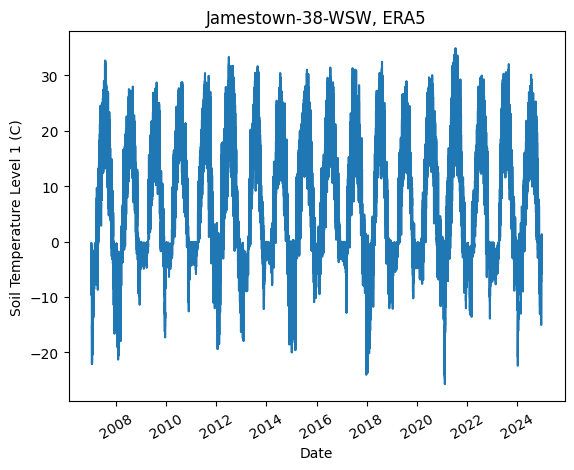

In [7]:
ERA5_jamestown_df = data_cleaning(data_path=raw_path,
                                  ismn_sites_path=c.SITE_SURVEY_PATH,
                                  station=c.JAMESTOWN_NAME,
                                  system=ERA5,
                                  key_variable=ERA5_short_var_name,
                                  date_range=c.DATE_RANGE)
data_reporting(df=ERA5_jamestown_df,
               variable=ERA5_short_var_name,
               station_name=c.JAMESTOWN_NAME,
               system=ERA5,
               ylabel=ERA5_long_var_name)

### 2.3 Gobblers Knob

#### ASCAT

There are 3620 nulls out of 36140 datapoints (0.1% missing).
Summary statistics:


,backscatter40,swath_indicator,as_des_pass,sat_id
count,32520.000000,32520.000000,32520.000000,32520.000000
mean,-11.629826,0.429982,0.503475,3.716082
std,1.476238,0.495081,0.499996,0.746541
min,-15.863902,0.000000,0.000000,3.000000
25%,-12.957079,0.000000,0.000000,3.000000
50%,-11.829261,0.000000,1.000000,4.000000
75%,-10.211492,1.000000,1.000000,4.000000
max,-7.769168,1.000000,1.000000,5.000000


Show head of df:


,backscatter40,swath_indicator,as_des_pass,sat_id
time,,,,
2007-01-01 20:00:00+00:00,-12.790222,1,1,3
2007-01-02 06:00:00+00:00,-13.280205,0,0,3
2007-01-02 07:00:00+00:00,-12.628483,1,0,3
2007-01-02 23:00:00+00:00,-12.695719,0,1,3
2007-01-03 05:00:00+00:00,-13.297269,0,0,3


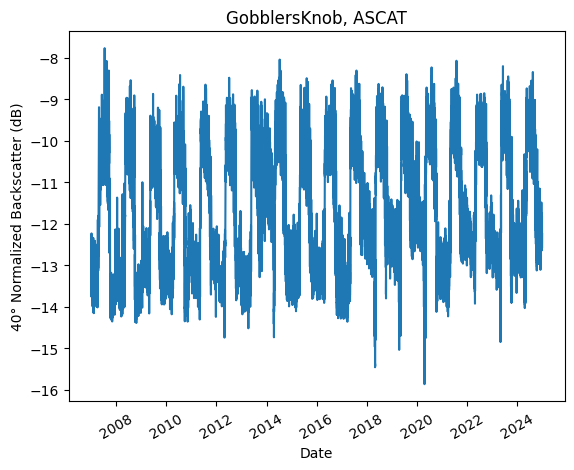

In [8]:
ASCAT_gobblers_knob_df = data_cleaning(data_path=raw_path,
                                       ismn_sites_path=c.SITE_SURVEY_PATH,
                                       station=c.GOBBLERS_KNOB_NAME,
                                       system=ASCAT,
                                       key_variable=ASCAT_short_var_name,
                                       date_range=c.DATE_RANGE)
data_reporting(df=ASCAT_gobblers_knob_df,
               variable=ASCAT_short_var_name,
               station_name=c.GOBBLERS_KNOB_NAME,
               system=ASCAT,
               ylabel=ASCAT_long_var_name)

#### ERA5

There are 0 nulls out of 27760 datapoints (0.0% missing).
Summary statistics:


,skt,stl1,stl2,swvl1,swvl2,sd
count,26300.000000,26300.000000,26300.000000,26300.000000,26300.000000,26300.000000
mean,-4.542267,1.721769,1.829484,0.342364,0.339904,0.054055
std,14.776735,7.955984,6.806094,0.039371,0.036234,0.066494
min,-47.079605,-32.260240,-27.000840,0.178779,0.199497,0.000000
25%,-16.061051,-3.308914,-2.082649,0.320459,0.319510,0.000000
50%,-3.180084,-0.840057,-1.193481,0.338007,0.333198,0.021519
75%,8.312645,8.556930,7.840897,0.366587,0.355937,0.093913
max,27.581390,25.048218,20.554535,0.439427,0.439467,0.301415


Show head of df:


,skt,stl1,stl2,swvl1,swvl2,sd
time,,,,,,
2007-01-01 00:00:00+00:00,-20.696045,-1.519684,-1.797882,0.337943,0.339708,0.040285
2007-01-01 06:00:00+00:00,-24.803726,-2.377106,-1.761078,0.337870,0.339609,0.040257
2007-01-01 12:00:00+00:00,-27.683731,-3.595123,-1.779083,0.339439,0.339627,0.040276
2007-01-01 18:00:00+00:00,-27.510590,-2.932556,-1.795288,0.339660,0.339517,0.040318
2007-01-02 00:00:00+00:00,-25.937057,-2.167572,-1.825165,0.339676,0.339394,0.040354


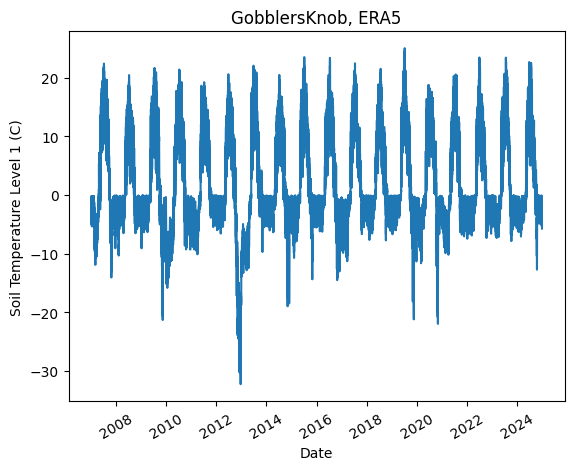

In [9]:
ERA5_gobblers_knob_df = data_cleaning(data_path=raw_path,
                                      ismn_sites_path=c.SITE_SURVEY_PATH,
                                      station=c.GOBBLERS_KNOB_NAME,
                                      system=ERA5,
                                      key_variable=ERA5_short_var_name,
                                      date_range=c.DATE_RANGE)
data_reporting(df=ERA5_gobblers_knob_df,
               variable=ERA5_short_var_name,
               station_name=c.GOBBLERS_KNOB_NAME,
               system=ERA5,
               ylabel=ERA5_long_var_name)

### 2.4 Nenana

#### ASCAT

There are 3433 nulls out of 32538 datapoints (0.11% missing).
Summary statistics:


,backscatter40,swath_indicator,as_des_pass,sat_id
count,29105.000000,29105.000000,29105.000000,29105.000000
mean,-10.732013,0.443773,0.496925,3.713795
std,1.211291,0.496837,0.499999,0.746623
min,-13.780949,0.000000,0.000000,3.000000
25%,-11.801822,0.000000,0.000000,3.000000
50%,-10.593150,0.000000,0.000000,4.000000
75%,-9.633761,1.000000,1.000000,4.000000
max,-7.459589,1.000000,1.000000,5.000000


Show head of df:


,backscatter40,swath_indicator,as_des_pass,sat_id
time,,,,
2007-01-01 20:00:00+00:00,-11.646178,1,1,3
2007-01-01 21:00:00+00:00,-12.336268,0,1,3
2007-01-02 06:00:00+00:00,-12.234253,0,0,3
2007-01-02 07:00:00+00:00,-11.359132,1,0,3
2007-01-02 19:00:00+00:00,-11.386372,1,1,3


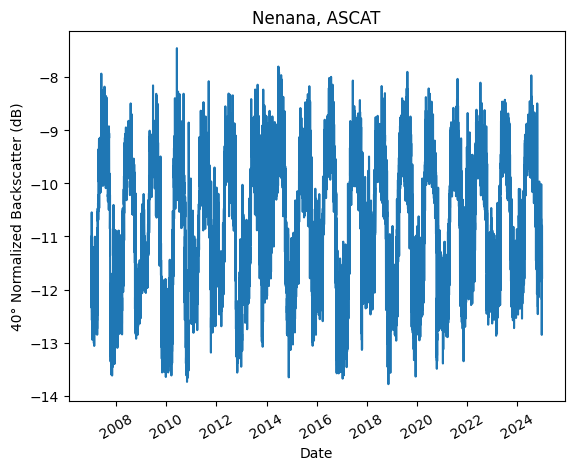

In [10]:
ASCAT_nenana_df = data_cleaning(data_path=raw_path,
                                ismn_sites_path=c.SITE_SURVEY_PATH,
                                station=c.NENANA_NAME,
                                system=ASCAT,
                                key_variable=ASCAT_short_var_name,
                                date_range=c.DATE_RANGE)
data_reporting(df=ASCAT_nenana_df,
               variable=ASCAT_short_var_name,
               station_name=c.NENANA_NAME,
               system=ASCAT,
               ylabel=ASCAT_long_var_name)

#### ERA5

There are 0 nulls out of 27760 datapoints (0.0% missing).
Summary statistics:


,skt,stl1,stl2,swvl1,swvl2,sd
count,26300.000000,26300.000000,26300.000000,26300.000000,26300.000000,26300.000000
mean,-1.286650,2.152065,2.166538,0.306980,0.291030,0.020375
std,15.910109,11.040534,9.569241,0.055240,0.052831,0.030314
min,-49.884293,-34.949005,-26.566010,0.116114,0.156593,0.000000
25%,-13.826553,-5.726677,-4.206634,0.277750,0.258748,0.000000
50%,-0.610962,-0.522034,-0.698273,0.313374,0.293380,0.001014
75%,12.189423,12.127228,11.144020,0.344583,0.327672,0.033185
max,35.094270,29.949066,23.848938,0.439606,0.439801,0.128733


Show head of df:


,skt,stl1,stl2,swvl1,swvl2,sd
time,,,,,,
2007-01-01 00:00:00+00:00,-25.815186,-14.547028,-13.553741,0.281837,0.251985,0.017716
2007-01-01 06:00:00+00:00,-29.313492,-15.621246,-13.614593,0.282038,0.251993,0.017776
2007-01-01 12:00:00+00:00,-28.863419,-16.983795,-14.027130,0.281853,0.251676,0.017790
2007-01-01 18:00:00+00:00,-21.246918,-16.424744,-14.209351,0.282043,0.251687,0.017800
2007-01-02 00:00:00+00:00,-17.323776,-16.605072,-14.405243,0.282104,0.251762,0.018454


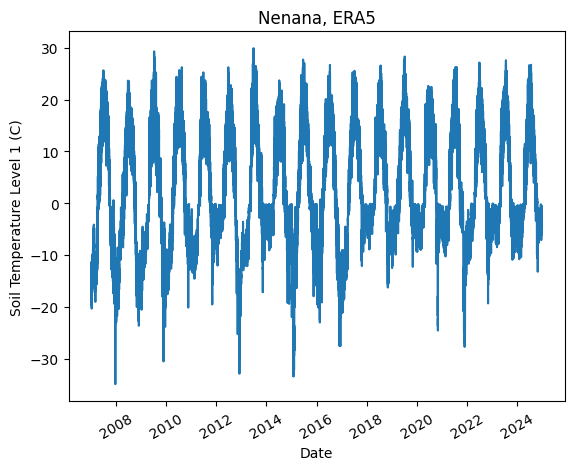

In [11]:
ERA5_nenana_df = data_cleaning(data_path=raw_path,
                               ismn_sites_path=c.SITE_SURVEY_PATH,
                               station=c.NENANA_NAME,
                               system=ERA5,
                               key_variable=ERA5_short_var_name,
                               date_range=c.DATE_RANGE)
data_reporting(df=ERA5_nenana_df,
               variable=ERA5_short_var_name,
               station_name=c.NENANA_NAME,
               system=ERA5,
               ylabel=ERA5_long_var_name)

### 2.5 L23

#### ASCAT

There are 874 nulls out of 14374 datapoints (0.06% missing).
Summary statistics:


,backscatter40,swath_indicator,as_des_pass,sat_id
count,13500.000000,13500.000000,13500.000000,13500.000000
mean,-11.809968,0.475037,0.504815,3.717037
std,1.496498,0.499395,0.499995,0.748413
min,-16.494514,0.000000,0.000000,3.000000
25%,-13.098708,0.000000,0.000000,3.000000
50%,-11.981903,0.000000,1.000000,4.000000
75%,-10.503685,1.000000,1.000000,4.000000
max,-7.121807,1.000000,1.000000,5.000000


Show head of df:


,backscatter40,swath_indicator,as_des_pass,sat_id
time,,,,
2007-01-02 04:00:00+00:00,-12.918723,0,1,3
2007-01-02 16:00:00+00:00,-12.326420,1,0,3
2007-01-03 04:00:00+00:00,-14.347024,0,1,3
2007-01-03 15:00:00+00:00,-13.486931,1,0,3
2007-01-05 03:00:00+00:00,-13.790267,1,1,3


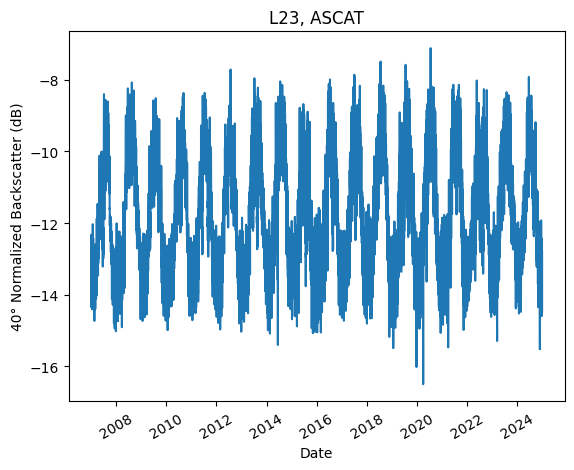

In [12]:
ASCAT_L23_df = data_cleaning(data_path=raw_path,
                             ismn_sites_path=c.SITE_SURVEY_PATH,
                             station=c.L23_NAME,
                             system=ASCAT,
                             key_variable=ASCAT_short_var_name,
                             date_range=c.DATE_RANGE)
data_reporting(df=ASCAT_L23_df,
               variable=ASCAT_short_var_name,
               station_name=c.L23_NAME,
               system=ASCAT,
               ylabel=ASCAT_long_var_name)

#### ERA5

There are 0 nulls out of 27760 datapoints (0.0% missing).
Summary statistics:


,skt,stl1,stl2,swvl1,swvl2,sd
count,26300.000000,26300.000000,26300.000000,26300.000000,26300.000000,26300.000000
mean,-6.942997,0.426651,0.422966,0.369136,0.366048,0.019796
std,14.627938,6.228625,5.134695,0.034965,0.034061,0.025915
min,-49.623672,-14.649292,-10.191315,0.255090,0.279266,0.000000
25%,-18.551606,-4.107712,-3.627022,0.340822,0.338136,0.000799
50%,-5.488434,-1.238403,-0.927277,0.365359,0.360548,0.010080
75%,2.858376,5.040169,5.442787,0.401984,0.398455,0.028099
max,28.218536,17.009247,11.938019,0.443202,0.435056,0.149500


Show head of df:


,skt,stl1,stl2,swvl1,swvl2,sd
time,,,,,,
2007-01-01 00:00:00+00:00,-28.576904,-4.203278,-3.368195,0.390922,0.359087,0.043311
2007-01-01 06:00:00+00:00,-6.235382,-4.168121,-3.407562,0.390925,0.359033,0.043271
2007-01-01 12:00:00+00:00,-21.847794,-3.837311,-3.333771,0.390923,0.359037,0.043201
2007-01-01 18:00:00+00:00,-25.227386,-3.942322,-3.271851,0.390914,0.359017,0.043242
2007-01-02 00:00:00+00:00,-25.021042,-4.083588,-3.284149,0.388183,0.358971,0.043293


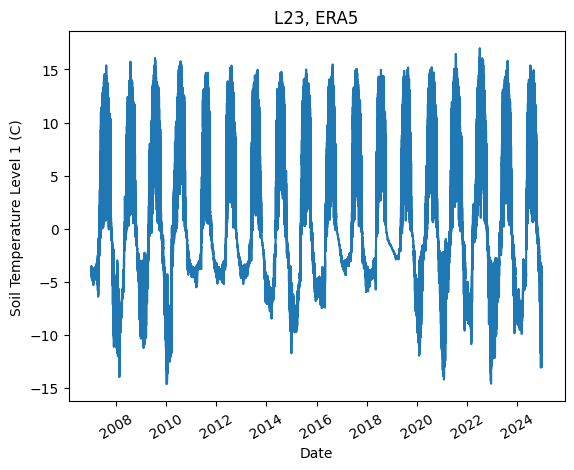

In [13]:
ERA5_L23_df = data_cleaning(data_path=raw_path,
                               ismn_sites_path=c.SITE_SURVEY_PATH,
                               station=c.L23_NAME,
                               system=ERA5,
                               key_variable=ERA5_short_var_name,
                               date_range=c.DATE_RANGE)
data_reporting(df=ERA5_L23_df,
               variable=ERA5_short_var_name,
               station_name=c.L23_NAME,
               system=ERA5,
               ylabel=ERA5_long_var_name)

### 2.6 L38

#### ASCAT

There are 1594 nulls out of 14489 datapoints (0.11% missing).
Summary statistics:


,backscatter40,swath_indicator,as_des_pass,sat_id
count,12895.000000,12895.000000,12895.000000,12895.000000
mean,-11.825687,0.503761,0.501745,3.712679
std,1.179467,0.500005,0.500016,0.747182
min,-15.653297,0.000000,0.000000,3.000000
25%,-12.854373,0.000000,0.000000,3.000000
50%,-12.000610,1.000000,1.000000,4.000000
75%,-10.820934,1.000000,1.000000,4.000000
max,-7.204072,1.000000,1.000000,5.000000


Show head of df:


,backscatter40,swath_indicator,as_des_pass,sat_id
time,,,,
2007-01-02 04:00:00+00:00,-13.265300,0,1,3
2007-01-02 16:00:00+00:00,-13.208417,1,0,3
2007-01-03 04:00:00+00:00,-13.032414,0,1,3
2007-01-03 15:00:00+00:00,-13.790648,1,0,3
2007-01-05 03:00:00+00:00,-13.257554,1,1,3


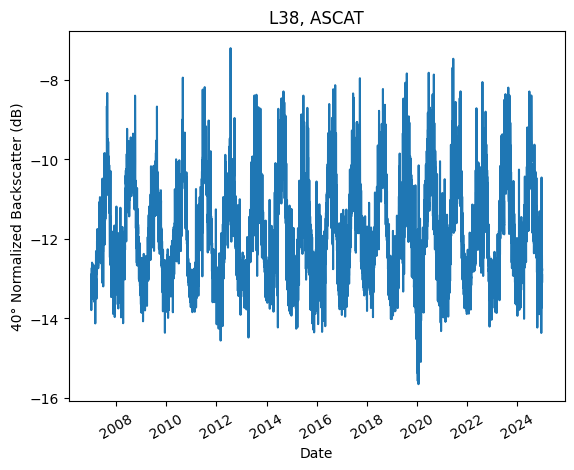

In [14]:
ASCAT_L38_df = data_cleaning(data_path=raw_path,
                             ismn_sites_path=c.SITE_SURVEY_PATH,
                             station=c.L38_NAME,
                             system=ASCAT,
                             key_variable=ASCAT_short_var_name,
                             date_range=c.DATE_RANGE)
data_reporting(df=ASCAT_L38_df,
               variable=ASCAT_short_var_name,
               station_name=c.L38_NAME,
               system=ASCAT,
               ylabel=ASCAT_long_var_name)

#### ERA5

There are 0 nulls out of 27760 datapoints (0.0% missing).
Summary statistics:


,skt,stl1,stl2,swvl1,swvl2,sd
count,26300.000000,26300.000000,26300.000000,26300.000000,26300.000000,26300.000000
mean,-6.213562,0.493967,0.491729,0.358316,0.355742,0.015785
std,14.337100,6.602513,5.408195,0.038169,0.036208,0.024256
min,-50.707657,-18.951782,-13.287384,0.236652,0.263150,0.000000
25%,-17.373653,-3.774269,-3.733322,0.330387,0.327531,0.001002
50%,-4.810303,-0.832916,-0.523392,0.357794,0.350611,0.008512
75%,3.336838,5.435394,5.704102,0.390077,0.386632,0.020531
max,28.859161,17.397919,11.712616,0.433919,0.431335,0.171600


Show head of df:


,skt,stl1,stl2,swvl1,swvl2,sd
time,,,,,,
2007-01-01 00:00:00+00:00,-26.596436,-4.507965,-3.622101,0.375846,0.373552,0.038162
2007-01-01 06:00:00+00:00,-4.776398,-4.418121,-3.655609,0.375849,0.373376,0.038092
2007-01-01 12:00:00+00:00,-17.908340,-4.003326,-3.540802,0.377663,0.371717,0.037956
2007-01-01 18:00:00+00:00,-22.252777,-4.108337,-3.445679,0.377669,0.371575,0.037992
2007-01-02 00:00:00+00:00,-23.868698,-4.310150,-3.456024,0.375870,0.370354,0.038016


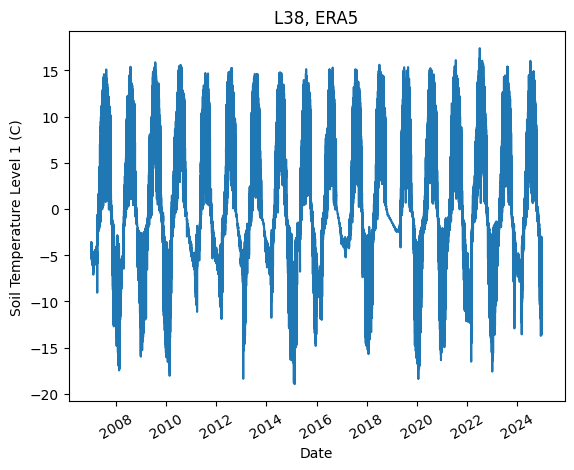

In [15]:
ERA5_L38_df = data_cleaning(data_path=raw_path,
                            ismn_sites_path=c.SITE_SURVEY_PATH,
                            station=c.L38_NAME,
                            system=ERA5,
                            key_variable=ERA5_short_var_name,
                            date_range=c.DATE_RANGE)
data_reporting(df=ERA5_L38_df,
               variable=ERA5_short_var_name,
               station_name=c.L38_NAME,
               system=ERA5,
               ylabel=ERA5_long_var_name)

### 2.7 NST-07

#### ASCAT

There are 1049 nulls out of 15088 datapoints (0.07% missing).
Summary statistics:


,backscatter40,swath_indicator,as_des_pass,sat_id
count,14039.000000,14039.000000,14039.000000,14039.000000
mean,-13.714801,0.491203,0.498896,3.716789
std,2.183975,0.499940,0.500017,0.747316
min,-18.695620,0.000000,0.000000,3.000000
25%,-15.650910,0.000000,0.000000,3.000000
50%,-12.974967,0.000000,0.000000,4.000000
75%,-11.928774,1.000000,1.000000,4.000000
max,-9.411098,1.000000,1.000000,5.000000


Show head of df:


,backscatter40,swath_indicator,as_des_pass,sat_id
time,,,,
2007-01-02 03:00:00+00:00,-18.340450,1,1,3
2007-01-02 14:00:00+00:00,-17.415730,0,0,3
2007-01-03 14:00:00+00:00,-16.352602,0,0,3
2007-01-04 04:00:00+00:00,-18.040010,0,1,3
2007-01-04 15:00:00+00:00,-17.644730,1,0,3


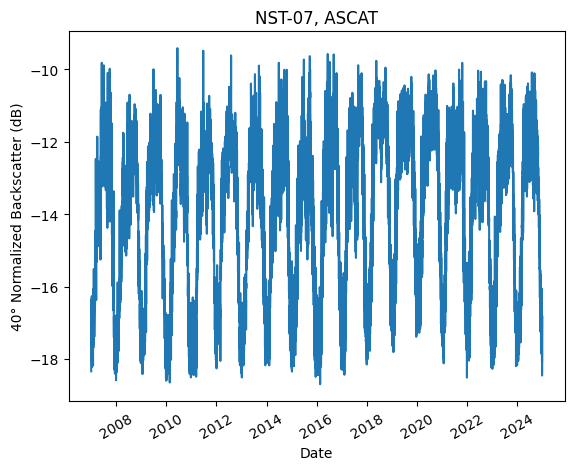

In [16]:
ASCAT_NST_07_df = data_cleaning(data_path=raw_path,
                                ismn_sites_path=c.SITE_SURVEY_PATH,
                                station=c.NST_07_NAME,
                                system=ASCAT,
                                key_variable=ASCAT_short_var_name,
                                date_range=c.DATE_RANGE)
data_reporting(df=ASCAT_NST_07_df,
               variable=ASCAT_short_var_name,
               station_name=c.NST_07_NAME,
               system=ASCAT,
               ylabel=ASCAT_long_var_name)

#### ERA5

There are 0 nulls out of 27760 datapoints (0.0% missing).
Summary statistics:


,skt,stl1,stl2,swvl1,swvl2,sd
count,26300.000000,26300.000000,26300.000000,26300.000000,26300.000000,26300.000000
mean,-0.045047,3.110299,3.158882,0.352128,0.349301,0.005712
std,12.741599,7.152360,6.074722,0.038713,0.036459,0.012818
min,-42.922165,-17.119934,-11.769653,0.131246,0.169917,0.000000
25%,-8.646797,-2.110992,-1.975784,0.332050,0.329109,0.000000
50%,1.566544,1.824951,2.524475,0.349409,0.347575,0.000427
75%,8.809128,9.005295,8.840347,0.379687,0.374517,0.004856
max,30.209595,22.347748,17.622100,0.437379,0.432863,0.085296


Show head of df:


,skt,stl1,stl2,swvl1,swvl2,sd
time,,,,,,
2007-01-01 00:00:00+00:00,-19.205810,-11.910309,-8.459991,0.327979,0.340639,0.009668
2007-01-01 06:00:00+00:00,-4.485382,-5.877106,-7.806000,0.327967,0.340616,0.010309
2007-01-01 12:00:00+00:00,-15.113434,-7.050201,-6.419708,0.330574,0.337583,0.012370
2007-01-01 18:00:00+00:00,-16.969574,-8.873962,-6.463257,0.330565,0.337548,0.012723
2007-01-02 00:00:00+00:00,-17.505417,-9.601166,-6.819305,0.330429,0.336967,0.012949


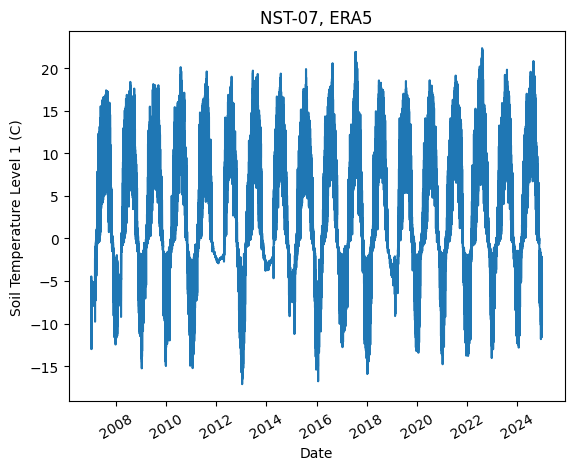

In [17]:
ERA5_NST_07_df = data_cleaning(data_path=raw_path,
                               ismn_sites_path=c.SITE_SURVEY_PATH,
                               station=c.NST_07_NAME,
                               system=ERA5,
                               key_variable=ERA5_short_var_name,
                               date_range=c.DATE_RANGE)
data_reporting(df=ERA5_NST_07_df,
               variable=ERA5_short_var_name,
               station_name=c.NST_07_NAME,
               system=ERA5,
               ylabel=ERA5_long_var_name)

### 2.8 NST-09

#### ASCAT

There are 1423 nulls out of 14768 datapoints (0.1% missing).
Summary statistics:


,backscatter40,swath_indicator,as_des_pass,sat_id
count,13345.000000,13345.000000,13345.000000,13345.000000
mean,-13.599529,0.489771,0.487523,3.710828
std,2.154390,0.499914,0.499863,0.746750
min,-19.681623,0.000000,0.000000,3.000000
25%,-15.369110,0.000000,0.000000,3.000000
50%,-12.889750,0.000000,0.000000,4.000000
75%,-11.836084,1.000000,1.000000,4.000000
max,-9.696083,1.000000,1.000000,5.000000


Show head of df:


,backscatter40,swath_indicator,as_des_pass,sat_id
time,,,,
2007-01-02 03:00:00+00:00,-18.221373,1,1,3
2007-01-02 14:00:00+00:00,-17.126863,0,0,3
2007-01-03 14:00:00+00:00,-15.837445,0,0,3
2007-01-04 04:00:00+00:00,-17.808882,0,1,3
2007-01-04 15:00:00+00:00,-17.277155,1,0,3


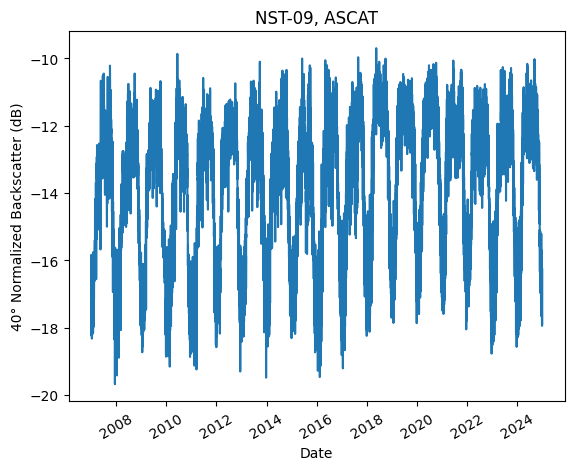

In [18]:
ASCAT_NST_09_df = data_cleaning(data_path=raw_path,
                                ismn_sites_path=c.SITE_SURVEY_PATH,
                                station=c.NST_09_NAME,
                                system=ASCAT,
                                key_variable=ASCAT_short_var_name,
                                date_range=c.DATE_RANGE)
data_reporting(df=ASCAT_NST_09_df,
               variable=ASCAT_short_var_name,
               station_name=c.NST_09_NAME,
               system=ASCAT,
               ylabel=ASCAT_long_var_name)

#### ERA5

There are 0 nulls out of 27760 datapoints (0.0% missing).
Summary statistics:


,skt,stl1,stl2,swvl1,swvl2,sd
count,26300.000000,26300.000000,26300.000000,26300.000000,26300.000000,26300.000000
mean,-0.045047,3.110299,3.158882,0.352128,0.349301,0.005712
std,12.741599,7.152360,6.074722,0.038713,0.036459,0.012818
min,-42.922165,-17.119934,-11.769653,0.131246,0.169917,0.000000
25%,-8.646797,-2.110992,-1.975784,0.332050,0.329109,0.000000
50%,1.566544,1.824951,2.524475,0.349409,0.347575,0.000427
75%,8.809128,9.005295,8.840347,0.379687,0.374517,0.004856
max,30.209595,22.347748,17.622100,0.437379,0.432863,0.085296


Show head of df:


,skt,stl1,stl2,swvl1,swvl2,sd
time,,,,,,
2007-01-01 00:00:00+00:00,-19.205810,-11.910309,-8.459991,0.327979,0.340639,0.009668
2007-01-01 06:00:00+00:00,-4.485382,-5.877106,-7.806000,0.327967,0.340616,0.010309
2007-01-01 12:00:00+00:00,-15.113434,-7.050201,-6.419708,0.330574,0.337583,0.012370
2007-01-01 18:00:00+00:00,-16.969574,-8.873962,-6.463257,0.330565,0.337548,0.012723
2007-01-02 00:00:00+00:00,-17.505417,-9.601166,-6.819305,0.330429,0.336967,0.012949


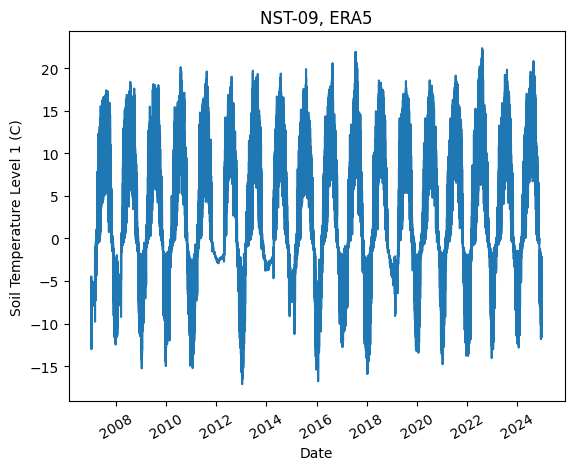

In [19]:
ERA5_NST_09_df = data_cleaning(data_path=raw_path,
                               ismn_sites_path=c.SITE_SURVEY_PATH,
                               station=c.NST_09_NAME,
                               system=ERA5,
                               key_variable=ERA5_short_var_name,
                               date_range=c.DATE_RANGE)
data_reporting(df=ERA5_NST_09_df,
               variable=ERA5_short_var_name,
               station_name=c.NST_09_NAME,
               system=ERA5,
               ylabel=ERA5_long_var_name)

### 2.9 SOD012

#### ASCAT

There are 3793 nulls out of 37371 datapoints (0.1% missing).
Summary statistics:


,backscatter40,swath_indicator,as_des_pass,sat_id
count,33578.000000,33578.000000,33578.000000,33578.000000
mean,-10.420756,0.430043,0.501132,3.717911
std,0.989236,0.495089,0.500006,0.748430
min,-14.228875,0.000000,0.000000,3.000000
25%,-11.059022,0.000000,0.000000,3.000000
50%,-10.242341,0.000000,1.000000,4.000000
75%,-9.668062,1.000000,1.000000,4.000000
max,-7.152429,1.000000,1.000000,5.000000


Show head of df:


,backscatter40,swath_indicator,as_des_pass,sat_id
time,,,,
2007-01-01 08:00:00+00:00,-11.544338,1,1,3
2007-01-01 19:00:00+00:00,-11.142731,1,0,3
2007-01-02 11:00:00+00:00,-11.569245,0,1,3
2007-01-02 17:00:00+00:00,-11.303937,0,0,3
2007-01-02 19:00:00+00:00,-11.309603,1,0,3


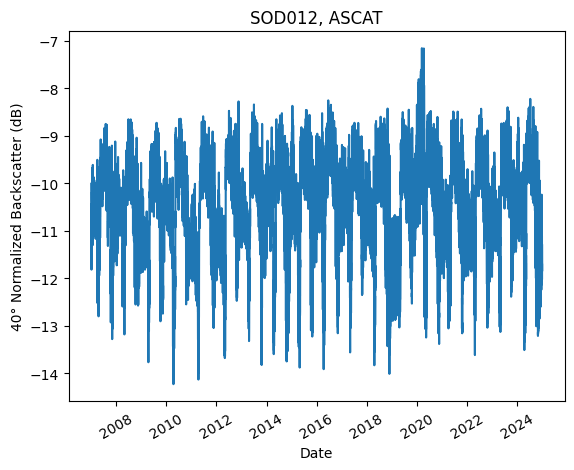

In [20]:
ASCAT_SOD012_df = data_cleaning(data_path=raw_path,
                                ismn_sites_path=c.SITE_SURVEY_PATH,
                                station=c.SOD012_NAME,
                                system=ASCAT,
                                key_variable=ASCAT_short_var_name,
                                date_range=c.DATE_RANGE)
data_reporting(df=ASCAT_SOD012_df,
               variable=ASCAT_short_var_name,
               station_name=c.SOD012_NAME,
               system=ASCAT,
               ylabel=ASCAT_long_var_name)

#### ERA5

There are 0 nulls out of 27760 datapoints (0.0% missing).
Summary statistics:


,skt,stl1,stl2,swvl1,swvl2,sd
count,26300.000000,26300.000000,26300.000000,26300.000000,26300.000000,26300.000000
mean,1.080498,2.821373,3.029417,0.452740,0.449465,0.074947
std,10.362081,7.192382,6.063834,0.036111,0.034926,0.095203
min,-34.091843,-15.353729,-6.475250,0.310796,0.335384,0.000000
25%,-5.943390,-2.280045,-1.619606,0.428037,0.424159,0.000000
50%,0.465714,-0.403748,-0.617233,0.447942,0.444592,0.020607
75%,9.273270,8.731476,8.399979,0.473199,0.471203,0.140687
max,30.046540,26.531800,21.632477,0.574494,0.573648,0.435823


Show head of df:


,skt,stl1,stl2,swvl1,swvl2,sd
time,,,,,,
2007-01-01 00:00:00+00:00,-0.487061,-1.742340,-1.438507,0.454398,0.462999,0.026584
2007-01-01 06:00:00+00:00,-5.454132,-1.631012,-1.431000,0.455012,0.462427,0.027838
2007-01-01 12:00:00+00:00,-6.562653,-1.929108,-1.423615,0.456764,0.462003,0.027819
2007-01-01 18:00:00+00:00,-3.264496,-2.182556,-1.418335,0.457076,0.461511,0.027457
2007-01-02 00:00:00+00:00,-3.403839,-2.845306,-1.426727,0.457077,0.460899,0.027545


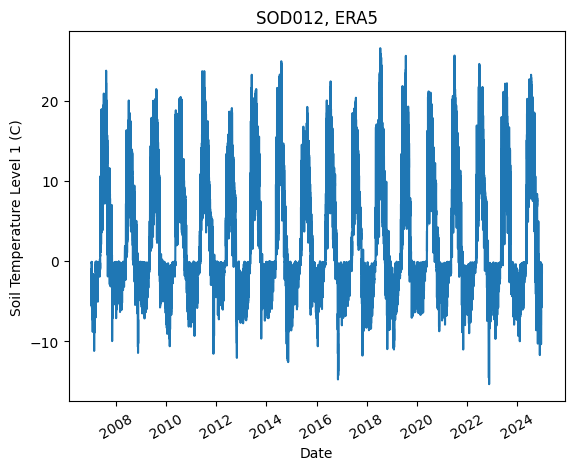

In [21]:
ERA5_SOD012_df = data_cleaning(data_path=raw_path,
                               ismn_sites_path=c.SITE_SURVEY_PATH,
                               station=c.SOD012_NAME,
                               system=ERA5,
                               key_variable=ERA5_short_var_name,
                               date_range=c.DATE_RANGE)
data_reporting(df=ERA5_SOD012_df,
               variable=ERA5_short_var_name,
               station_name=c.SOD012_NAME,
               system=ERA5,
               ylabel=ERA5_long_var_name)

### 2.10 SOD103

#### ASCAT

There are 3793 nulls out of 37371 datapoints (0.1% missing).
Summary statistics:


,backscatter40,swath_indicator,as_des_pass,sat_id
count,33578.000000,33578.000000,33578.000000,33578.000000
mean,-10.420756,0.430043,0.501132,3.717911
std,0.989236,0.495089,0.500006,0.748430
min,-14.228875,0.000000,0.000000,3.000000
25%,-11.059022,0.000000,0.000000,3.000000
50%,-10.242341,0.000000,1.000000,4.000000
75%,-9.668062,1.000000,1.000000,4.000000
max,-7.152429,1.000000,1.000000,5.000000


Show head of df:


,backscatter40,swath_indicator,as_des_pass,sat_id
time,,,,
2007-01-01 08:00:00+00:00,-11.544338,1,1,3
2007-01-01 19:00:00+00:00,-11.142731,1,0,3
2007-01-02 11:00:00+00:00,-11.569245,0,1,3
2007-01-02 17:00:00+00:00,-11.303937,0,0,3
2007-01-02 19:00:00+00:00,-11.309603,1,0,3


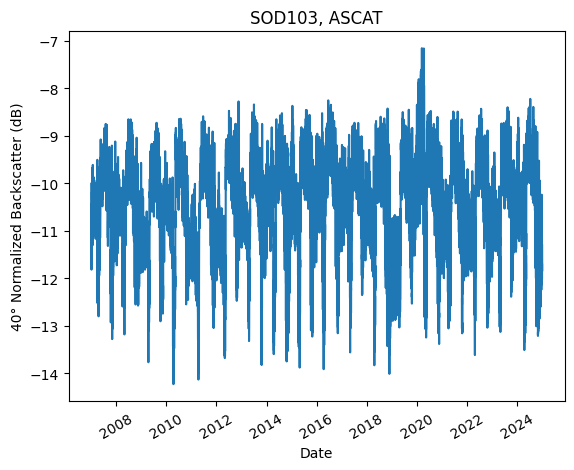

In [22]:
ASCAT_SOD103_df = data_cleaning(data_path=raw_path,
                                ismn_sites_path=c.SITE_SURVEY_PATH,
                                station=c.SOD103_NAME,
                                system=ASCAT,
                                key_variable=ASCAT_short_var_name,
                                date_range=c.DATE_RANGE)
data_reporting(df=ASCAT_SOD103_df,
               variable=ASCAT_short_var_name,
               station_name=c.SOD103_NAME,
               system=ASCAT,
               ylabel=ASCAT_long_var_name)

#### ERA5

There are 0 nulls out of 27760 datapoints (0.0% missing).
Summary statistics:


,skt,stl1,stl2,swvl1,swvl2,sd
count,26300.000000,26300.000000,26300.000000,26300.000000,26300.000000,26300.000000
mean,1.080498,2.821373,3.029417,0.452740,0.449465,0.074947
std,10.362081,7.192382,6.063834,0.036111,0.034926,0.095203
min,-34.091843,-15.353729,-6.475250,0.310796,0.335384,0.000000
25%,-5.943390,-2.280045,-1.619606,0.428037,0.424159,0.000000
50%,0.465714,-0.403748,-0.617233,0.447942,0.444592,0.020607
75%,9.273270,8.731476,8.399979,0.473199,0.471203,0.140687
max,30.046540,26.531800,21.632477,0.574494,0.573648,0.435823


Show head of df:


,skt,stl1,stl2,swvl1,swvl2,sd
time,,,,,,
2007-01-01 00:00:00+00:00,-0.487061,-1.742340,-1.438507,0.454398,0.462999,0.026584
2007-01-01 06:00:00+00:00,-5.454132,-1.631012,-1.431000,0.455012,0.462427,0.027838
2007-01-01 12:00:00+00:00,-6.562653,-1.929108,-1.423615,0.456764,0.462003,0.027819
2007-01-01 18:00:00+00:00,-3.264496,-2.182556,-1.418335,0.457076,0.461511,0.027457
2007-01-02 00:00:00+00:00,-3.403839,-2.845306,-1.426727,0.457077,0.460899,0.027545


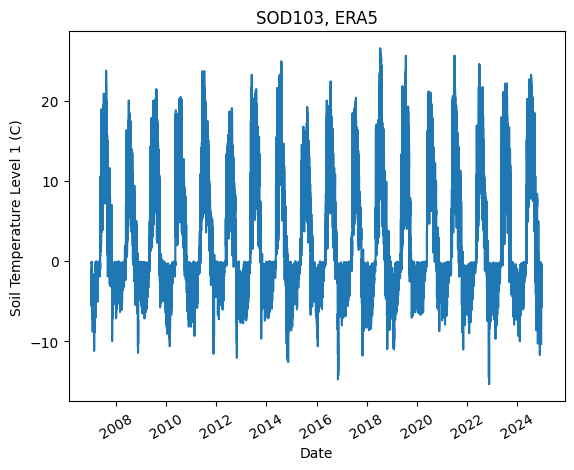

In [23]:
ERA5_SOD103_df = data_cleaning(data_path=raw_path,
                               ismn_sites_path=c.SITE_SURVEY_PATH,
                               station=c.SOD103_NAME,
                               system=ERA5,
                               key_variable=ERA5_short_var_name,
                               date_range=c.DATE_RANGE)
data_reporting(df=ERA5_SOD103_df,
               variable=ERA5_short_var_name,
               station_name=c.SOD103_NAME,
               system=ERA5,
               ylabel=ERA5_long_var_name)